In [1]:
import torch
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 名字：", torch.cuda.get_device_name(0))
    print("CUDA 版本：", torch.version.cuda)


CUDA 可用： True
GPU 名字： NVIDIA GeForce RTX 4060 Laptop GPU
CUDA 版本： 11.8


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# =====================================================
# 1. 加载你【真实】的特征数据集
# =====================================================
def load_real_datasets():
    FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")

    files = [
        "MultiModel_Clean_Balanced_TEST_5k_Features.csv",
        "HC3_Clean_Balanced_TEST_5k_Features.csv",
        "LLMDetect_Clean_Balanced_TEST_5k_Features.csv",
        "MAGE_test_Clean_Balanced_TEST_5k_Features.csv",
        "DAIGT_Clean_Balanced_TEST_5k_Features.csv"
    ]

    dfs = []
    for f in files:
        df = pd.read_csv(FEATURE_DIR / f)
        df["source"] = f.split("_")[0]  # 记录来源（可选）
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)
    print(f"Total samples loaded: {len(data)}")

    # 标签
    y = data["label"].values

    # 特征列（你 extractor 里定义的）
    feature_cols = [c for c in data.columns if c.startswith("feat_") or c.startswith("pos_")]
    X = data[feature_cols].values

    # -------- Feature Groups（核心！）--------
    feature_groups = {
        "statistical": [i for i, c in enumerate(feature_cols)
                        if any(k in c for k in ["avg_sent", "var_sent", "ttr", "punc", "perplexity"])],
        "syntactic":   [i for i, c in enumerate(feature_cols)
                        if "pos_" in c or "dep_depth" in c],
        "semantic":    [i for i, c in enumerate(feature_cols)
                        if "coherence" in c]
    }

    return X, y, feature_cols, feature_groups


# =====================================================
# 2. 统一评估函数
# =====================================================
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro"),
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPR": average_precision_score(y_test, y_prob)
    }


# =====================================================
# 3. 模型
# =====================================================
def train_xgb(X_train, y_train):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


def train_ebm(X_train, y_train):
    model = ExplainableBoostingClassifier(
        random_state=RANDOM_SEED,
        interactions=0
    )
    model.fit(X_train, y_train)
    return model


# =====================================================
# 4. Feature Ablation（F1–F4）
# =====================================================
def run_feature_ablation(X, y, feature_groups):
    results = []

    ablations = {
        "F1: Statistical only": feature_groups["statistical"],
        "F2: Stat + Syntactic": feature_groups["statistical"] + feature_groups["syntactic"],
        "F3: Stat + Semantic": feature_groups["statistical"] + feature_groups["semantic"],
        "F4: All features": list(range(X.shape[1]))
    }

    for name, idxs in ablations.items():
        print(f"\n=== Running {name} ===")

        X_sub = X[:, idxs]

        X_train, X_test, y_train, y_test = train_test_split(
            X_sub, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
        )

        xgb = train_xgb(X_train, y_train)
        ebm = train_ebm(X_train, y_train)

        results.append(evaluate(xgb, X_test, y_test, f"XGBoost ({name})"))
        results.append(evaluate(ebm, X_test, y_test, f"EBM ({name})"))

    return pd.DataFrame(results)


# =====================================================
# 5. 主函数
# =====================================================
def main():
    X, y, feature_names, feature_groups = load_real_datasets()

    results = run_feature_ablation(X, y, feature_groups)

    print("\n========== FINAL ABLATION RESULTS ==========")
    print(results.round(4))

    # 可直接导出成 LaTeX
    results.to_csv("ablation_feature_results.csv", index=False)


if __name__ == "__main__":
    main()


Total samples loaded: 25000

=== Running F1: Statistical only ===

=== Running F2: Stat + Syntactic ===

=== Running F3: Stat + Semantic ===

=== Running F4: All features ===

========== FINAL ABLATION RESULTS ==========
                            Model  Accuracy  Macro-F1   AUROC    AUPR
0  XGBoost (F1: Statistical only)    0.7424    0.7419  0.8233  0.8428
1      EBM (F1: Statistical only)    0.7100    0.7058  0.7843  0.7894
2  XGBoost (F2: Stat + Syntactic)    0.7580    0.7572  0.8431  0.8610
3      EBM (F2: Stat + Syntactic)    0.7156    0.7124  0.7926  0.8004
4   XGBoost (F3: Stat + Semantic)    0.7382    0.7376  0.8245  0.8442
5       EBM (F3: Stat + Semantic)    0.7156    0.7115  0.7861  0.7924
6      XGBoost (F4: All features)    0.7616    0.7608  0.8472  0.8643
7          EBM (F4: All features)    0.7182    0.7151  0.7948  0.8026


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
def load_features(csv_path):
    df = pd.read_csv(csv_path)
    feature_cols = [c for c in df.columns if c.startswith("feat_") or c.startswith("pos_")]
    X = df[feature_cols].fillna(df[feature_cols].mean())
    y = df["label"]
    return X, y
def train_and_eval(X_train, y_train, X_test, y_test, tag):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric="logloss",
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "Setting": tag,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro"),
        "AUROC": roc_auc_score(y_test, y_prob)
    }
def run_no_clustering(train_csv, test_csv):
    X_train, y_train = load_features(train_csv)
    X_test, y_test = load_features(test_csv)
    return train_and_eval(
        X_train, y_train, X_test, y_test,
        tag="No clustering"
    )
from sklearn.cluster import KMeans

def run_kmeans(train_csv, test_csv, n_clusters=6):
    X_train, y_train = load_features(train_csv)
    X_test, y_test = load_features(test_csv)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    train_cluster = kmeans.fit_predict(X_train_s)
    test_cluster = kmeans.predict(X_test_s)

    # ⭐ cluster 作为附加特征
    X_train_aug = np.c_[X_train_s, train_cluster]
    X_test_aug = np.c_[X_test_s, test_cluster]

    return train_and_eval(
        X_train_aug, y_train,
        X_test_aug, y_test,
        tag="KMeans clustering"
    )
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

def run_dbscan(train_csv, test_csv, eps=1.3, min_samples=15):
    X_train, y_train = load_features(train_csv)
    X_test, y_test = load_features(test_csv)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # PCA 降噪（你原来就有，继续用）
    pca = PCA(n_components=0.9, random_state=42)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    train_cluster = db.fit_predict(X_train_pca)

    # DBSCAN 对 test：最近邻 cluster（简化版）
    test_cluster = np.full(len(X_test), -1)

    X_train_aug = np.c_[X_train_s, train_cluster]
    X_test_aug = np.c_[X_test_s, test_cluster]

    return train_and_eval(
        X_train_aug, y_train,
        X_test_aug, y_test,
        tag="DBSCAN clustering"
    )
if __name__ == "__main__":
    FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")

    TRAIN = FEATURE_DIR / "MultiModel_Clean_Balanced_TRAIN_5k_Features.csv"
    TEST  = FEATURE_DIR / "MultiModel_Clean_Balanced_TEST_5k_Features.csv"

    results = []

    print("\n=== Running No Clustering ===")
    results.append(run_no_clustering(TRAIN, TEST))

    print("\n=== Running KMeans ===")
    results.append(run_kmeans(TRAIN, TEST))

    print("\n=== Running DBSCAN ===")
    results.append(run_dbscan(TRAIN, TEST))

    df_results = pd.DataFrame(results)
    print("\n========== CLUSTERING ABLATION RESULTS ==========")
    print(df_results)


=== Running No Clustering ===

=== Running KMeans ===

=== Running DBSCAN ===

========== CLUSTERING ABLATION RESULTS ==========
             Setting  Accuracy  Macro-F1     AUROC
0      No clustering    0.6312  0.631124  0.691680
1  KMeans clustering    0.6330  0.632938  0.687069
2  DBSCAN clustering    0.6336  0.633554  0.691468



🚀 Dataset: DAIGT_Clean_Balanced

🚀 Dataset: HC3_Clean_Balanced

🚀 Dataset: LLMDetect_Clean_Balanced

🚀 Dataset: MAGE_test_Clean_Balanced

🚀 Dataset: MultiModel_Clean_Balanced

========== TRAINING SIZE SENSITIVITY RESULTS ==========
                  dataset        method  train_size      auc       f1
     DAIGT_Clean_Balanced Full training        5000 0.996326 0.976949
       HC3_Clean_Balanced Full training        5000 0.999211 0.991984
 LLMDetect_Clean_Balanced Full training        5000 0.862667 0.775157
 MAGE_test_Clean_Balanced Full training        5000 0.870664 0.792578
MultiModel_Clean_Balanced Full training        5000 0.704848 0.630321
     DAIGT_Clean_Balanced Pattern-based          12 0.927804 0.867444
       HC3_Clean_Balanced Pattern-based          12 0.989958 0.984578
 LLMDetect_Clean_Balanced Pattern-based          12 0.588204 0.564266
 MAGE_test_Clean_Balanced Pattern-based          12 0.537737 0.547283
MultiModel_Clean_Balanced Pattern-based          12 0.545234 0.5432

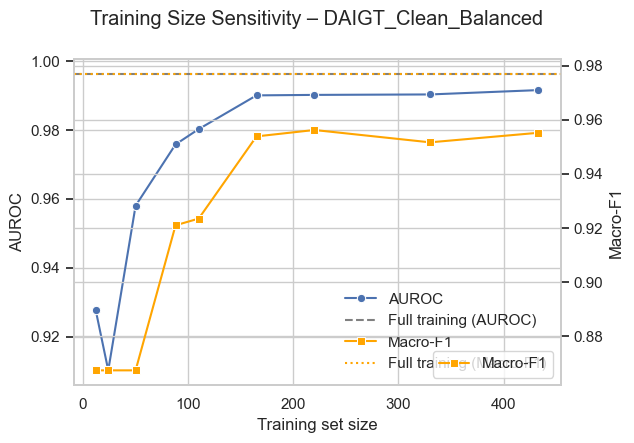

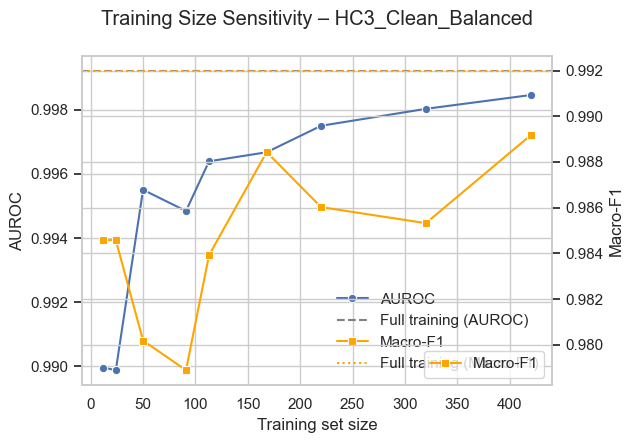

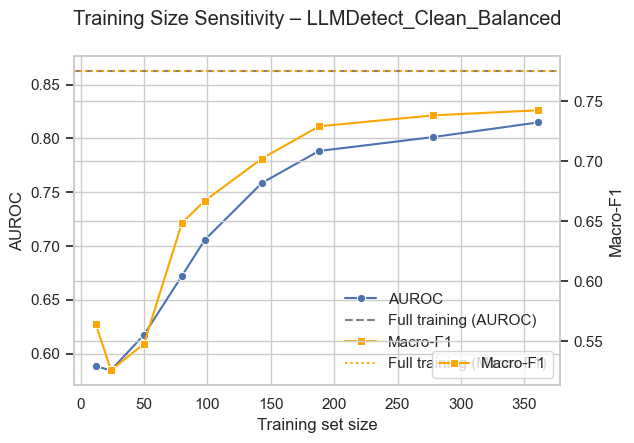

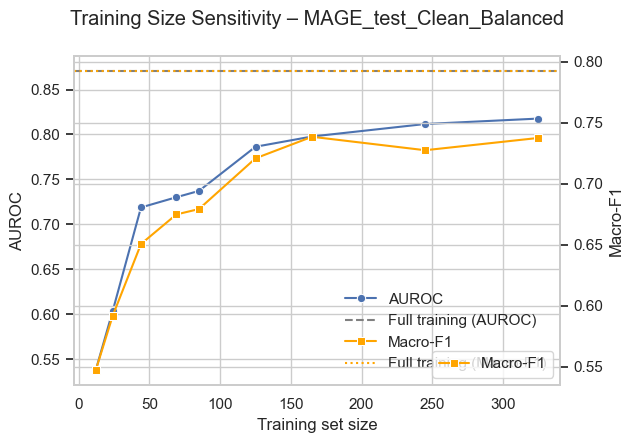

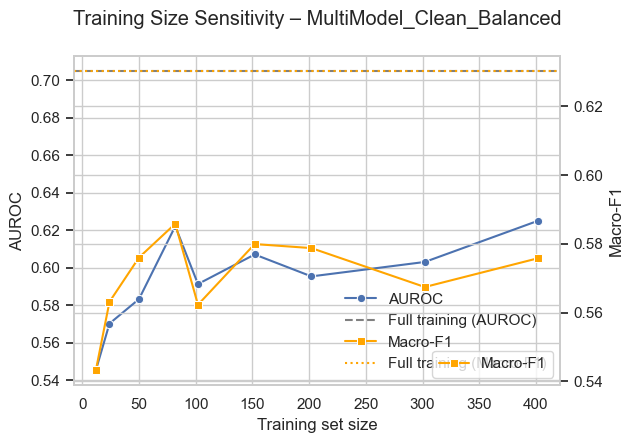

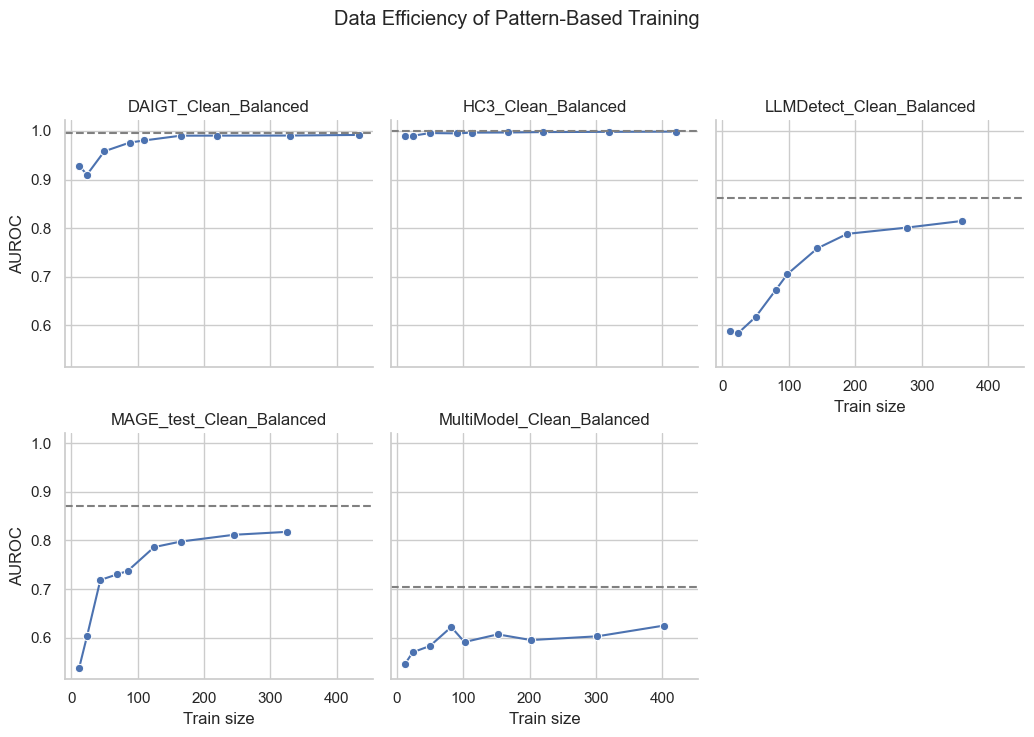

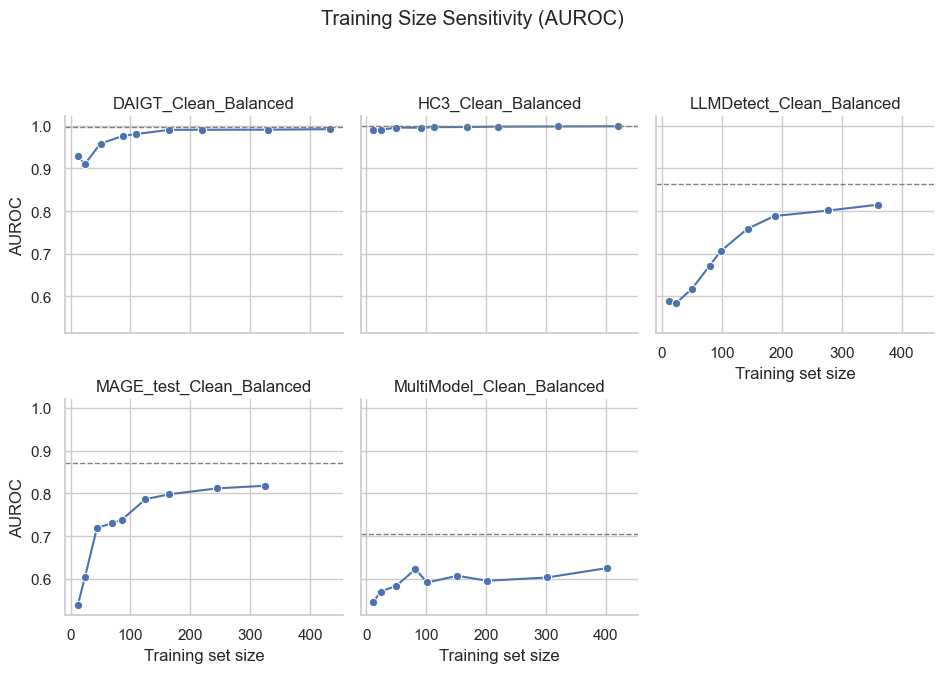

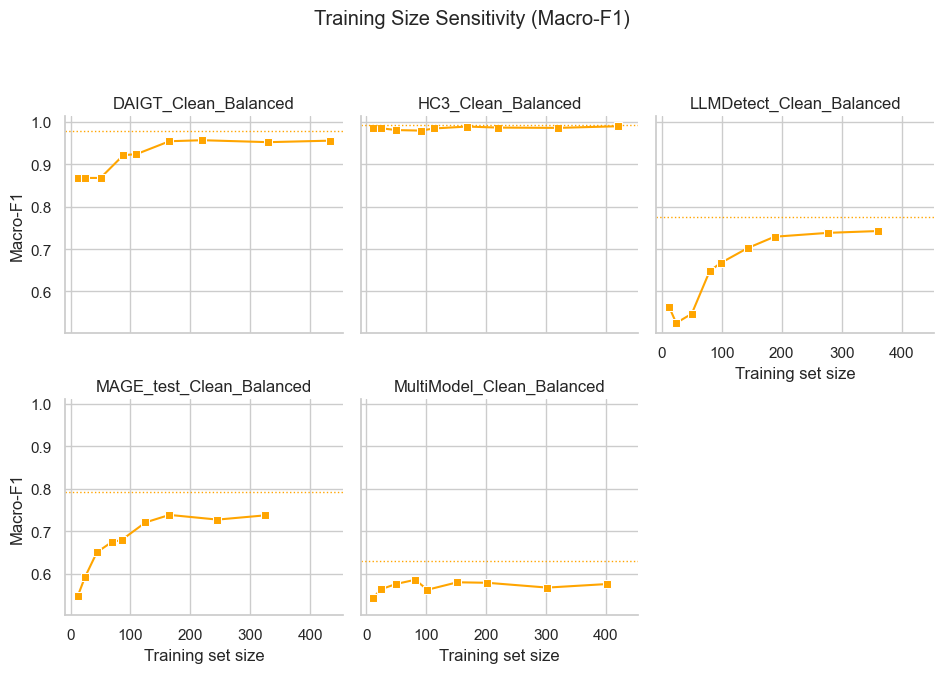

In [18]:
import pandas as pd
from pathlib import Path
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)
def load_xy(csv_path):
    df = pd.read_csv(csv_path)

    feature_cols = [
        c for c in df.columns
        if c.startswith("feat_") or c.startswith("pos_")
    ]

    X = df[feature_cols]
    y = df["label"]

    return X, y
PATTERN_CONFIGS = [
    {"samples_per_pattern": 2, "patterns_per_class": 3},
    {"samples_per_pattern": 3, "patterns_per_class": 4},
    {"samples_per_pattern": 5, "patterns_per_class": 5},
    {"samples_per_pattern": 8, "patterns_per_class": 6},
    {"samples_per_pattern": 10, "patterns_per_class": 7},
    {"samples_per_pattern": 15, "patterns_per_class": 8},
    {"samples_per_pattern": 20, "patterns_per_class": 9},
    {"samples_per_pattern": 30, "patterns_per_class": 10},
    {"samples_per_pattern": 40, "patterns_per_class": 11},
    # {"samples_per_pattern": 50, "patterns_per_class": 12},
    # {"samples_per_pattern": 60, "patterns_per_class": 13},
    # {"samples_per_pattern": 100, "patterns_per_class": 14},
]
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from collections import Counter

def train_and_evaluate_xgb(train_csv, test_csv):
    X_train, y_train = load_xy(train_csv)
    X_test, y_test = load_xy(test_csv)

    if len(set(y_train)) < 2:
        return {
            "accuracy": None,
            "f1": None,
            "auc": None,
            "train_size": len(y_train),
            "note": f"single_class_train ({Counter(y_train)})"
        }

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "train_size": len(y_train),
        "note": "ok"
    }
def build_pattern_training_set(clustered_file,
                               samples_per_pattern,
                               patterns_per_class):
    df = pd.read_csv(clustered_file)

    selected_rows = []

    for label_value in [0, 1]:
        df_class = df[df["label"] == label_value]
        grouped = df_class.groupby("cluster")

        clusters_sorted = sorted(
            grouped,
            key=lambda x: len(x[1]),
            reverse=True
        )[:patterns_per_class]

        for cid, g in clusters_sorted:
            sampled = g.sample(
                min(samples_per_pattern, len(g)),
                random_state=42
            )
            selected_rows.append(sampled)

    if not selected_rows:
        return None

    return (
        pd.concat(selected_rows)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )
results = []

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")
    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"

    if not test_file.exists():
        continue

    print(f"\n🚀 Dataset: {dataset}")

    # Full training baseline
    full_metrics = train_and_evaluate_xgb(train_file, test_file)
    results.append({
        "dataset": dataset,
        "method": "Full training",
        **full_metrics
    })

    # Pattern-based varying sizes
    for cfg in PATTERN_CONFIGS:
        pattern_train = build_pattern_training_set(
            train_file,
            cfg["samples_per_pattern"],
            cfg["patterns_per_class"]
        )

        if pattern_train is None:
            continue

        tmp_path = RESULT_DIR / "tmp_pattern_train.csv"
        pattern_train.to_csv(tmp_path, index=False)

        metrics = train_and_evaluate_xgb(tmp_path, test_file)
        results.append({
            "dataset": dataset,
            "method": "Pattern-based",
            "samples_per_pattern": cfg["samples_per_pattern"],
            "patterns_per_class": cfg["patterns_per_class"],
            **metrics
        })
print("\n========== TRAINING SIZE SENSITIVITY RESULTS ==========")
df = pd.DataFrame(results)

# 只保留 Pattern-based 的 curve
pattern_df = df[df.method == "Pattern-based"]

# Full training baseline（每个 dataset 一个）
full_df = df[df.method == "Full training"]

summary_cols = [
    "dataset", "method", "train_size", "auc", "f1"
]

print(
    df[summary_cols]
    .sort_values(["method", "train_size"])
    .to_string(index=False)
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

for dataset in pattern_df["dataset"].unique():
    fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

    sub_pattern = pattern_df[pattern_df.dataset == dataset]
    sub_full = full_df[full_df.dataset == dataset]

    # ===== AUC curve =====
    sns.lineplot(
        data=sub_pattern,
        x="train_size",
        y="auc",
        marker="o",
        ax=ax1,
        label="AUROC"
    )

    full_auc = sub_full["auc"].iloc[0]
    ax1.axhline(
        y=full_auc,
        linestyle="--",
        color="gray",
        label="Full training (AUROC)"
    )

    ax1.set_xlabel("Training set size")
    ax1.set_ylabel("AUROC")

    # ===== F1 curve =====
    ax2 = ax1.twinx()
    sns.lineplot(
        data=sub_pattern,
        x="train_size",
        y="f1",
        marker="s",
        color="orange",
        ax=ax2,
        label="Macro-F1"
    )

    full_f1 = sub_full["f1"].iloc[0]
    ax2.axhline(
        y=full_f1,
        linestyle=":",
        color="orange",
        label="Full training (Macro-F1)"
    )

    ax2.set_ylabel("Macro-F1")

    # ===== 合并 legend =====
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best",
        frameon=False
    )

    fig.suptitle(f"Training Size Sensitivity – {dataset}")
    fig.tight_layout()
    plt.show()
g = sns.FacetGrid(
    pattern_df,
    col="dataset",
    col_wrap=3,
    height=3.5,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="train_size",
    y="auc",
    marker="o"
)

for ax, dataset in zip(g.axes.flatten(), pattern_df["dataset"].unique()):
    full_auc = full_df[full_df.dataset == dataset]["auc"].iloc[0]
    ax.axhline(full_auc, linestyle="--", color="gray")

    ax.set_title(dataset)
    ax.set_xlabel("Train size")
    ax.set_ylabel("AUROC")

g.fig.suptitle("Data Efficiency of Pattern-Based Training", y=1.05)
plt.tight_layout()
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# 只保留 pattern-based
plot_df = pattern_df.copy()

# ===== AUROC =====
g_auc = sns.FacetGrid(
    plot_df,
    col="dataset",
    col_wrap=3,
    height=3.2,
    sharey=True
)

g_auc.map_dataframe(
    sns.lineplot,
    x="train_size",
    y="auc",
    marker="o"
)

for ax, dataset in zip(g_auc.axes.flatten(), plot_df["dataset"].unique()):
    full_auc = full_df[full_df.dataset == dataset]["auc"].iloc[0]
    ax.axhline(full_auc, linestyle="--", color="gray", linewidth=1)

    ax.set_title(dataset)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("AUROC")

g_auc.fig.suptitle(
    "Training Size Sensitivity (AUROC)",
    y=1.05
)

plt.tight_layout()
plt.show()


# ===== Macro-F1 =====
g_f1 = sns.FacetGrid(
    plot_df,
    col="dataset",
    col_wrap=3,
    height=3.2,
    sharey=True
)

g_f1.map_dataframe(
    sns.lineplot,
    x="train_size",
    y="f1",
    marker="s",
    color="orange"
)

for ax, dataset in zip(g_f1.axes.flatten(), plot_df["dataset"].unique()):
    full_f1 = full_df[full_df.dataset == dataset]["f1"].iloc[0]
    ax.axhline(full_f1, linestyle=":", color="orange", linewidth=1)

    ax.set_title(dataset)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro-F1")

g_f1.fig.suptitle(
    "Training Size Sensitivity (Macro-F1)",
    y=1.05
)

plt.tight_layout()
plt.show()
